# Epidemiological Time Series Forecasting & Plotting
### Integrating `epidatpy` (Delphi Epidata V5 API) with `auto-time-series`

This tutorial demonstrates how to fit diverse statistical forecasters with [`auto-time-series`](https://github.com/Afraz496/auto-time-series), evaluate models via rolling-origin backtests, and visualize results across multiple forecasting scenarios.

## Setup & Environment

Install the required libraries:
```bash
pip install -e . git+https://github.com/cmu-delphi/epidatpy.git
```

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from epidatpy import EpiDataContext, EpiRange

from autotimeseries import (
    AutoForecaster,
    backtest,
    plot_metric_by_horizon,
)
from autotimeseries.models import (
    AutoARIMAForecaster,
    ETSForecaster,
    NaiveForecaster,
    ThetaForecaster,
)

# Set plot styling defaults
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Ingesting Data via `epidatpy`

We query the Delphi V5 API snapshot endpoint for inpatient claims admissions (`claims_inpatient_adm_pct_claims_flu`) in California (`ca`).

In [2]:
epidata = EpiDataContext()

# Query Delphi V5 snapshot endpoint directly
df = epidata.epidata_snapshot(
    source="claims_inpatient",
    signals="claims_inpatient_adm_pct_claims_flu",
    geo_type="state",
    geo_values="ca",

    reference_time=EpiRange(20240101, 20260215),
).df()

# Convert reference_time to weekly time series
df["reference_time"] = pd.to_datetime(df["reference_time"])
y = (
    df.set_index("reference_time")["value"]
    .sort_index()
    .asfreq("D")
    .ffill()
    .resample("W-SUN")
    .mean()
    .astype(float)
    .rename("Weekly Inpatient Claims (% flu)")
)

display(y.head())

/Users/javiermtz/Library/Mobile Documents/com~apple~CloudDocs/code-projects/auto-time-series/.venv/lib/python3.12/site-packages/epidatpy/_auth.py:9: UserWarning: DELPHI_EPIDATA_KEY environment variable not set. Please set it to your Epidata API key to avoid rate limits. You can get a free key at: https://api.delphi.cmu.edu/epidata/admin/registration_form
  warnings.warn(


reference_time
2024-01-07    0.453684
2024-01-14    0.236010
2024-01-21    0.160317
2024-01-28    0.195574
2024-02-04    0.152667
Freq: W-SUN, Name: Weekly Inpatient Claims (% flu), dtype: float64

## A First Forecast with Uncertainty

Hold out the last 8 weeks, fit on the rest, and forecast that window with `.predict(horizon, level=[80, 95])`. Plotting the `ForecastResult` with `.plot(observed=y)` draws the point forecast and its nested 80% / 95% bands against the full series, so the forecast can be eyeballed against the held-out truth. The forecast line joins the last training point.

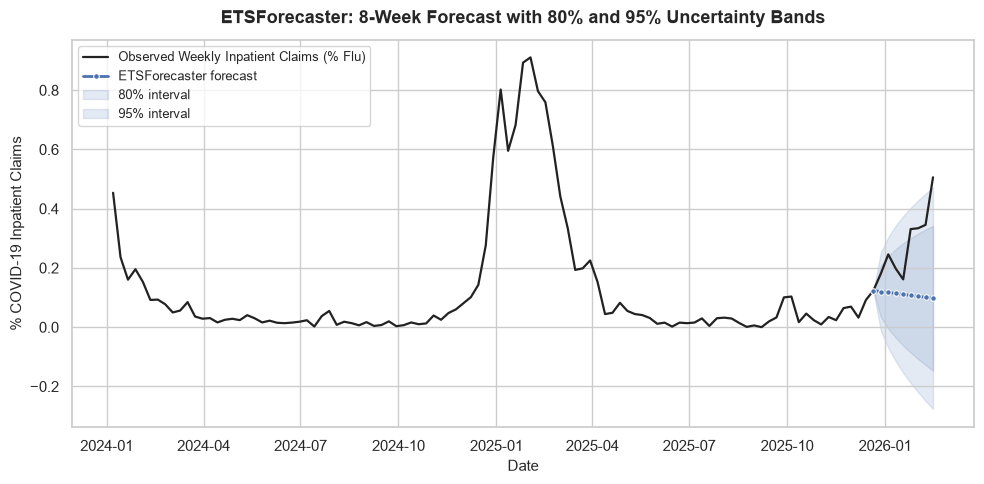

In [10]:
# One model's forecast with nested 80% and 95% uncertainty bands
y_train, y_test = y.iloc[:-8], y.iloc[-8:]
ets_fc = ETSForecaster().fit(y_train).predict(horizon=8, level=[80, 95])
ax = ets_fc.plot(
    observed = y,
    title="ETSForecaster: 8-Week Forecast with 80% and 95% Uncertainty Bands",
)
ax.set_xlabel("Date")
ax.set_ylabel("% COVID-19 Inpatient Claims")
ax.grid(True)
plt.show()

## Rolling-Origin Backtesting

Expanding-window splits score a model on data it never saw at fit time, avoiding look-ahead bias.

`backtest()` returns a `BacktestResult` with per-fold scores (`.scores`), every fold's out-of-sample predictions (`.predictions`), a `.summary()`, and a `.plot()` that overlays all rolling folds.

Backtest Scores Table:


,cutoff,score,n_train
0,2025-10-26,0.010361,95
1,2025-11-09,0.027186,97
2,2025-11-23,0.024530,99
3,2025-12-07,0.106275,101
4,2025-12-21,0.088923,103



Fold Predictions:


,cutoff,target_date,step,predicted,lower_80,upper_80,actual
0,2025-10-26,2025-11-02,1,0.023787,-0.065485,0.113059,0.009184
1,2025-10-26,2025-11-09,2,0.023928,-0.102322,0.150178,0.034341
2,2025-10-26,2025-11-16,3,0.024070,-0.130554,0.178694,0.023479
3,2025-11-09,2025-11-16,1,0.034407,-0.054014,0.122828,0.023479
4,2025-11-09,2025-11-23,2,0.034474,-0.090573,0.159520,0.064262


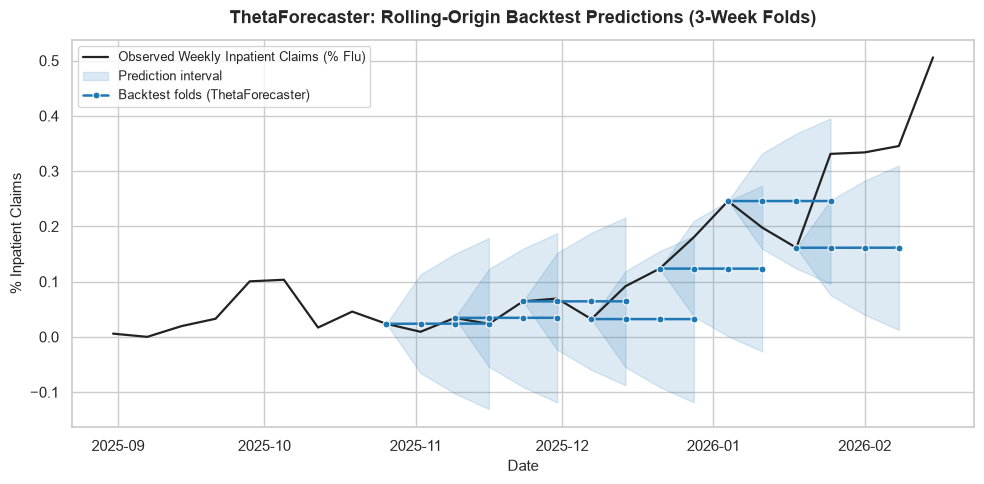

In [11]:
horizon = 3
initial = len(y) - 16

bt_result = backtest(
    ThetaForecaster(),
    y,
    horizon=horizon,
    initial=initial,
    step=2,
    metric="rmse",
)

print("Backtest Scores Table:")
display(bt_result.scores.head())

print("\nFold Predictions:")
display(bt_result.predictions.head())

# Visualize out-of-sample forecast trajectories across all cutoffs
ax = bt_result.plot(observed=y.iloc[-25:], title="ThetaForecaster: Rolling-Origin Backtest Predictions (3-Week Folds)")
ax.set_xlabel("Date")
ax.set_ylabel("% Inpatient Claims")
ax.grid(True)
plt.show()

## Forecast Accuracy by Horizon

Error usually grows with the forecast horizon. We backtest each candidate at horizons $h \in \{1, 2, 3, 4, 6\}$ and compare with `plot_metric_by_horizon()`.

/Users/javiermtz/Library/Mobile Documents/com~apple~CloudDocs/code-projects/auto-time-series/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/javiermtz/Library/Mobile Documents/com~apple~CloudDocs/code-projects/auto-time-series/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/javiermtz/Library/Mobile Documents/com~apple~CloudDocs/code-projects/auto-time-series/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/javiermtz/Library/Mobile Documents/com~apple~CloudDocs/code-pro

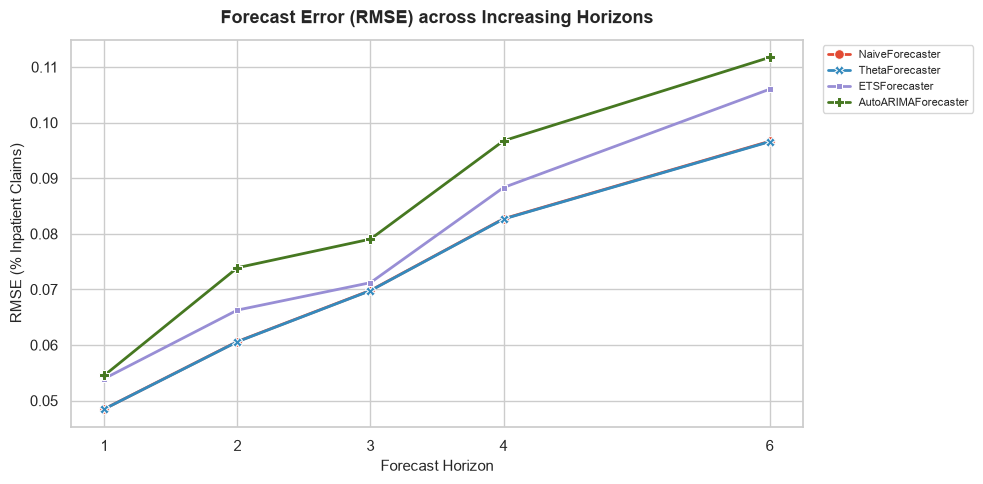

In [12]:
horizons = [1, 2, 3, 4, 6]
candidate_models = {
    "NaiveForecaster": NaiveForecaster(),
    "ThetaForecaster": ThetaForecaster(),
    "ETSForecaster": ETSForecaster(),
    "AutoARIMAForecaster": AutoARIMAForecaster(),
}

rows = []
for name, model in candidate_models.items():
    for h in horizons:
        res = backtest(model, y, horizon=h, initial=initial, metric="rmse")
        rows.append({
            "model": name,
            "horizon": h,
            "rmse": res.scores["score"].mean(),
        })

metrics_df = pd.DataFrame(rows)

ax = plot_metric_by_horizon(
    metrics_df=metrics_df,
    metric_col="rmse",
    title="Forecast Error (RMSE) across Increasing Horizons",
    ylabel="RMSE (% Inpatient Claims)",
    colors={
        "NaiveForecaster": "#E24A33",
        "ThetaForecaster": "#348ABD",
        "ETSForecaster": "#988ED5",
        "AutoARIMAForecaster": "#467821",
    },
    horizons=horizons,
)
plt.show()

## Automated Selection with `AutoForecaster`

`AutoForecaster` runs the rolling-origin backtest above for every candidate, ranks them by the chosen metric, and refits the winner on the full series. The leaderboard and the winning forecast:

AutoForecaster Leaderboard:


,model,score,status
0,ThetaForecaster,0.033873,ok
1,NaiveForecaster,0.033934,ok
2,AutoARIMAForecaster,0.038197,ok
3,ETSForecaster,0.038622,ok


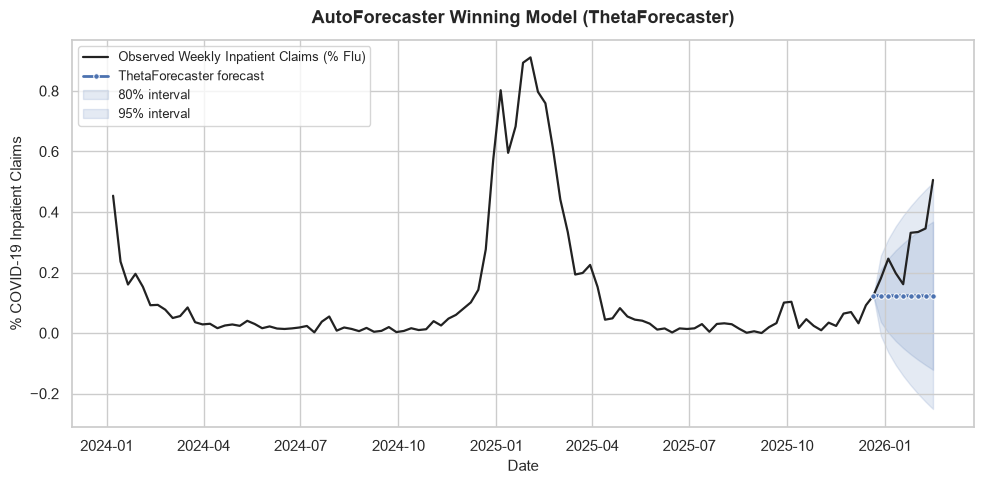

In [6]:
auto = AutoForecaster(
    models=[NaiveForecaster(), ThetaForecaster(), ETSForecaster(), AutoARIMAForecaster()],
    metric="rmse",
    validation_horizon=4,
)
auto.fit(y_train)

print("AutoForecaster Leaderboard:")
display(auto.leaderboard_)

auto_fc = auto.predict(horizon=8, level=[80, 95])
ax = auto_fc.plot(
    observed=y,
    title=f"AutoForecaster Winning Model ({auto.best_model_.__class__.__name__})",
)
ax.set_xlabel("Date")
ax.set_ylabel("% COVID-19 Inpatient Claims")
ax.grid(True)
plt.show()

## Comparing Every Candidate

`plot_all()` refits each candidate the selector kept and overlays their trajectories -- the visual complement to the leaderboard.

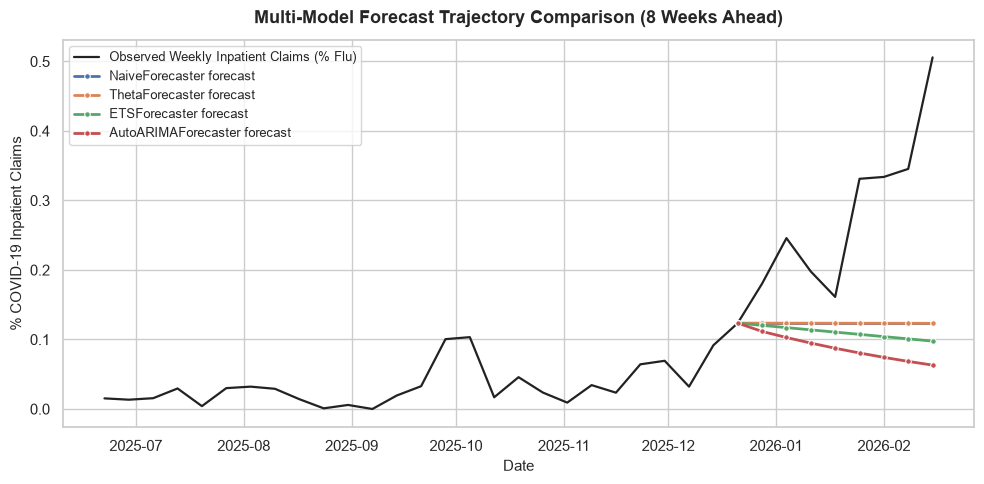

In [7]:
ax = auto.plot_all(
    horizon=8,
    observed=y.iloc[-35:],
    intervals=False,  # shade each candidate's 80% / 95% bands
    title="Multi-Model Forecast Trajectory Comparison (8 Weeks Ahead)",
)
ax.set_ylabel("% COVID-19 Inpatient Claims")
plt.show()